# Цыпышев ТА, Вар. 18

## Задача №3: Масштабирование данных и преобразование категориальных признаков

Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака. Какие методы Вы использовали для решения задачи и почему?

## Набор данных №2: Wine

Набор данных **Wine** из библиотеки `scikit-learn` содержит информацию о химическом составе вин из разных регионов, а также класс вина, который представляет собой категорию из трех классов (классов вин). Этот набор данных используется для классификации.

Данные состоят из 178 наблюдений и 13 признаков, которые представляют химические характеристики вина, такие как уровни различных химических компонентов, таких как алкоголь, пептиды, полифенолы и т.д.

Для получения дополнительной информации, примеров и методов работы с этим набором данных, вы можете перейти по следующей [ссылке на официальную документацию `scikit-learn`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine).

In [1]:
# Установим необходимые библиотеки (раскоментировать)
!pip install numpy pandas seaborn matplotlib scikit-learn


In [2]:
# Импортируем необходимые библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder


In [3]:
# Загружаем данные
wine = load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
target = pd.DataFrame(wine.target, columns=['target'])

In [4]:
# Сохраняем в файл CSV
data.to_csv('./wine_data.csv', index=False)
target.to_csv('./wine_target.csv', index=False)

## Решение

Замена числовых меток на категориальные значения

В оригинальном датасете load_wine() целевая переменная (target) представлена в виде чисел: 0, 1, 2. Эти значения соответствуют трем классам вина, но сами по себе они не несут смысловой нагрузки — они просто обозначают категории.

Чтобы сделать данные подходящими для заание о преобразование категориальных признаков, мы заменили числовые метки на строковые названия вин Каберне Совиньон, Мерло, Пино Нуар.

In [5]:
# Заменим числовые значения на строковые категории
target['target'] = target['target'].map({
    0: 'Каберне Совиньон',
    1: 'Мерло',
    2: 'Пино Нуар'
})

In [6]:
# Просмотрим первые несколько строк данных
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
target

,target
0,Каберне Совиньон
1,Каберне Совиньон
2,Каберне Совиньон
3,Каберне Совиньон
4,Каберне Совиньон
...,...
173,Пино Нуар
174,Пино Нуар
175,Пино Нуар
176,Пино Нуар


### 1. Масштабирование данных для одного признака:

Масштабирование данных позволяет привести все данные к единому масштабу, что важно для некоторых алгоритмов машинного обучения (например, для методов, чувствительных к масштабу данных, таких как линейные модели, SVM, KNN).

**Методы масштабирования:**
- **Min-Max Scaling** (нормализация): масштабирует данные в диапазон от 0 до 1. Этот метод подходит, если нужно привести данные к одному масштабу, сохраняя пропорции между значениями.
  $$ X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}} $$


In [8]:
# Масштабирование признака 'alcohol' с использованием MinMaxScaler
scaler_minmax = MinMaxScaler()
data['alcohol_minmax_scaled'] = scaler_minmax.fit_transform(data[['alcohol']])

In [9]:
# Просмотрим результаты масштабирования
data[['alcohol', 'alcohol_minmax_scaled']].head()

,alcohol,alcohol_minmax_scaled
0,14.23,0.842105
1,13.20,0.571053
2,13.16,0.560526
3,14.37,0.878947
4,13.24,0.581579


- **Standardization** (стандартизация): масштабирует данные так, чтобы они имели среднее значение 0 и стандартное отклонение 1. Этот метод полезен, если данные имеют распределение с выбросами.
  $$ X_{\text{scaled}} = \frac{X - \mu}{\sigma} $$
  где \(\mu\) — это среднее значение, а \(\sigma\) — стандартное отклонение.

In [10]:
# Масштабирование признака 'alcohol' с использованием StandardScaler
scaler = StandardScaler()
data['alcohol_scaled'] = scaler.fit_transform(data[['alcohol']])

In [11]:
# Просмотрим результаты масштабирования
data[['alcohol', 'alcohol_scaled']].head()

,alcohol,alcohol_scaled
0,14.23,1.518613
1,13.20,0.246290
2,13.16,0.196879
3,14.37,1.691550
4,13.24,0.295700


### 2. Преобразование категориальных признаков в количественные:
Для работы с категориальными признаками в машинном обучении часто используют методы, которые переводят их в числовые значения.

#### 2.1. **Label Encoding**:
**Label Encoding** — это метод, при котором каждому уникальному значению категориального признака присваивается уникальный числовой код. Например, для признака "Цвет" можно присвоить:
- Красный → 0
- Зеленый → 1
- Синий → 2

Этот метод полезен, если категориальные данные имеют порядковую структуру. Однако если категория не имеет порядка, этот метод может внести нежелательную искаженность.

In [12]:
# Для начала, преобразуем целевой признак в категориальный для примера
label_encoder = LabelEncoder()
target['target_label_encoded'] = label_encoder.fit_transform(target['target'])

In [13]:
# Посмотрим на результаты Label Encoding
target

,target,target_label_encoded
0,Каберне Совиньон,0
1,Каберне Совиньон,0
2,Каберне Совиньон,0
3,Каберне Совиньон,0
4,Каберне Совиньон,0
...,...,...
173,Пино Нуар,2
174,Пино Нуар,2
175,Пино Нуар,2
176,Пино Нуар,2


#### 2.2. **One-Hot Encoding**:
**One-Hot Encoding** — это метод, при котором для каждого уникального значения категориального признака создается новый бинарный столбец. Если признак имеет 3 категории, то после one-hot encoding будет 3 новых столбца, где для каждой строки будет установлено значение 1 для соответствующей категории и 0 для других.

**Пример:**
Для признака "Цвет" с уникальными значениями (Красный, Зеленый, Синий) после one-hot encoding получится:
- Красный → [1, 0, 0]
- Зеленый → [0, 1, 0]
- Синий → [0, 0, 1]

Этот метод лучше подходит для категориальных признаков без порядковой структуры.

In [14]:
# Теперь применим OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)
target_one_hot = onehot_encoder.fit_transform(target[['target']])

In [15]:
# Преобразуем результат в DataFrame и добавим к исходным данным
target_one_hot_df = pd.DataFrame(target_one_hot, columns=onehot_encoder.categories_[0])
target_with_onehot = pd.concat([target, target_one_hot_df], axis=1)


In [16]:
# Посмотрим на результаты One Hot Encoding
target_with_onehot

,target,target_label_encoded,Каберне Совиньон,Мерло,Пино Нуар
0,Каберне Совиньон,0,1.0,0.0,0.0
1,Каберне Совиньон,0,1.0,0.0,0.0
2,Каберне Совиньон,0,1.0,0.0,0.0
3,Каберне Совиньон,0,1.0,0.0,0.0
4,Каберне Совиньон,0,1.0,0.0,0.0
...,...,...,...,...,...
173,Пино Нуар,2,0.0,0.0,1.0
174,Пино Нуар,2,0.0,0.0,1.0
175,Пино Нуар,2,0.0,0.0,1.0
176,Пино Нуар,2,0.0,0.0,1.0


### Дополнительное задание: Построение диаграммы рассеяния

Постройте диаграмму рассеяния (scatter plot) для двух произвольных колонок из набора данных "Wine" (данные о вине).

Цель:
Визуализировать взаимосвязь между двумя признаками, выбрав любые два столбца из датасета.

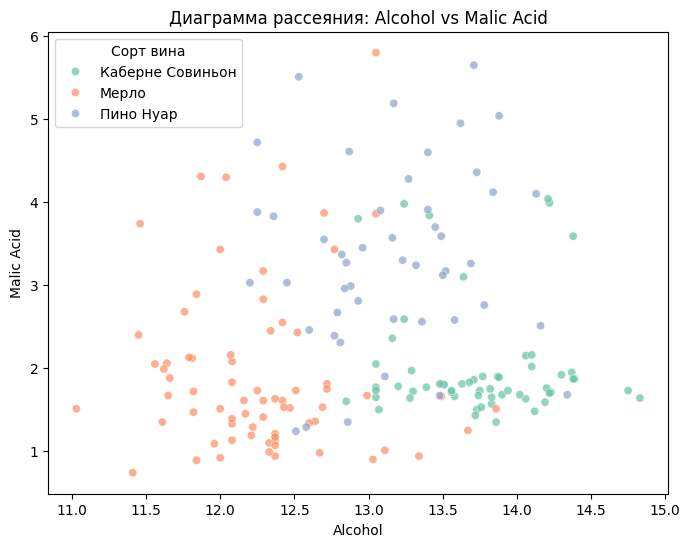

In [17]:
# Объединяем данные
data_with_target = data.copy()
data_with_target['target'] = target_with_onehot['target']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_with_target, x='alcohol', y='malic_acid', hue='target', palette='Set2', alpha=0.7)
plt.title('Диаграмма рассеяния: Alcohol vs Malic Acid')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.legend(title='Сорт вина')
plt.show()

### Использованные методы и причины их выбора:

#### 1. **Масштабирование данных**
**Метод:** Стандартизация (StandardScaler) или нормализация (MinMaxScaler)  
**Почему использовался:**  
- Многие модели машинного обучения (например, SVM, логистическая регрессия, KNN, нейронные сети) чувствительны к масштабу данных.  
- Масштабирование помогает ускорить обучение и повысить точность за счёт более быстрой сходимости градиентных методов.

**Преимущества:**
- Улучшает производительность чувствительных к масштабу моделей.
- Предотвращает доминирование признаков с большим масштабом.

**Недостатки:**
- Не все модели требуют масштабирования (например, деревья решений и случайный лес).
- Требует предварительного анализа, какой метод масштабирования подходит для конкретной задачи.

#### 2. **Label Encoding**
**Метод:** Замена категориальных значений целыми числами (например, “низкий” → 0, “средний” → 1, “высокий” → 2)  
**Почему использовался:**  
- Подходит для признаков с естественным порядком (ordinal data).
- Упрощает данные, позволяя моделям учитывать порядок значений.

**Преимущества:**
- Простота реализации.
- Сохраняет порядок категорий, если он имеет смысл.

**Недостатки:**
- Может ввести в заблуждение модель, если порядок не имеет смысла (например, города или имена).
- Модели могут трактовать расстояние между категориями как равное, что не всегда верно.

#### 3. **One-Hot Encoding**
**Метод:** Преобразование каждой категории в отдельный бинарный столбец.  
**Почему использовался:**  
- Идеален для номинативных категориальных признаков (например, "цвет", "тип продукта").

**Преимущества:**
- Избегает ложной интерпретации порядка между категориями.
- Работает корректно с большинством моделей.

**Недостатки:**
- Увеличивает размерность данных (особенно при большом количестве уникальных категорий).
- Может привести к разреженным матрицам (sparse data).

### Заключение:
- Для масштабирования данных можно использовать стандартализацию или нормализацию в зависимости от задачи.
- Для преобразования категориальных признаков в количественные можно использовать два метода: Label Encoding и One-Hot Encoding в зависимости от порядка категорий.

Оба этих этапа — масштабирование и преобразование категориальных признаков — являются важными шагами предобработки данных перед применением моделей машинного обучения.